# Comportamento dos controladores ao longo do dia

Trajetórias de temperatura de todos os controladores nos 9 cenários da matriz 3×3,
em episódios de 24 h.

**Separação por ambiente, deliberada.** Um agente treinado num ambiente que só
resfria e outro treinado com aquecimento bidirecional não podem ser sobrepostos no
mesmo gráfico — teriam autoridades de atuação diferentes, e a comparação diria
mais sobre o hardware simulado que sobre a política. Por isso há duas seções:

| Seção | Ambiente | Controladores |
|---|---|---|
| A | Sala de aula: 4 níveis discretos, **só resfria** | DQN (3 perfis), termostato, PI |
| B | Laboratório: carga contínua, **bidirecional** | TD3, SAC, PI bidirecional |

Figuras salvas em `plots_comportamento/`.


In [1]:
import sys, os, glob, json
sys.path.insert(0, os.path.abspath(".."))
import numpy.core
for sub in ("", ".numeric", ".multiarray", ".umath", "._multiarray_umath"):
    try:
        __import__("numpy.core" + sub); sys.modules["numpy._core" + sub] = sys.modules["numpy.core" + sub]
    except Exception: pass

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from stable_baselines3 import DQN, SAC, TD3

from config import ClassroomConfig, config_for_profile, config_for_lab2
from env import ClassroomACEnv
from wrappers import ActionRepeatWrapper
from baselines import PIController, ThermostatAgent
from scenarios import build_scenario_matrix
from metrics import run_episode, episode_metrics

SAVE = "../plots_comportamento"; os.makedirs(SAVE, exist_ok=True)
plt.rcParams.update({"figure.dpi": 105, "axes.grid": True, "grid.alpha": 0.25,
                     "font.size": 9})
SCEN = build_scenario_matrix()
fab = lambda cfg: ActionRepeatWrapper(ClassroomACEnv(config=cfg), repeat=2)

CORES = {
    "Termostato": "#e05561", "PI": "#c0392b",
    "DQN Agressivo": "#2b7bba", "DQN Equilibrado": "#4daf4a", "DQN Passivo": "#8c6bb1",
    "PI bidirecional": "#c0392b",
    "TD3 Precisao": "#2b7bba", "TD3 Equilibrado": "#4daf4a", "TD3 Economico": "#e8801a",
    "SAC Precisao": "#7fb3d5", "SAC Equilibrado": "#9ed19b", "SAC Economico": "#f5c18b",
}

def eixo_horas(ax, h0, h1, passo=6):
    t = np.arange(np.ceil(h0/passo)*passo, h1+0.1, passo)
    ax.set_xticks(t); ax.set_xticklabels([f"{int(x)%24:02d}h" for x in t], fontsize=7)
    ax.set_xlim(h0, h1)

def faixas_tarifa(ax, cfg, h0, h1):
    for h in np.arange(np.floor(h0), np.ceil(h1), 0.5):
        cor = {"ponta": "#e05561", "intermediario": "#f0ad4e"}.get(cfg.tariff.posto(h))
        if cor: ax.axvspan(h, h+0.5, color=cor, alpha=0.13, lw=0)

print(f"{len(SCEN)} cenários: " + ", ".join(s["id"] for s in SCEN))

9 cenários: C1, C2, C3, C4, C5, C6, C7, C8, C9


## Seção A — Sala de aula (discreto, só resfria)

Ambiente do manuscrito. Faixa de conforto larga [22, 26] °C em verde.

O que observar: onde cada controlador **assenta** a temperatura. O termostato
estaciona no teto (26 °C); os agentes de RL e o PI convergem para perto de 24 °C.
Nos cenários frios (C1–C3) nenhum controlador consegue subir a temperatura — o
equipamento só resfria.


In [2]:
CFG_A = ClassroomConfig()
ctrl_A = {
    "Termostato": (ThermostatAgent(CFG_A, deadband=0.0), True, CFG_A),
    "PI":         (PIController(CFG_A, kp=1.3, ki=0.2), True, CFG_A),
}
for perfil in ("Agressivo", "Equilibrado", "Passivo"):
    p = f"../models_paper/DQN_{perfil}_seed0.zip"
    if os.path.exists(p):
        ctrl_A[f"DQN {perfil}"] = (DQN.load(p, device="cpu"), False, config_for_profile(perfil))

def coletar(ctrl, cenarios):
    """{controlador: {cenario_id: DataFrame}}"""
    out = {}
    for nome, (ag, usa_info, cfg) in ctrl.items():
        out[nome] = {s["id"]: run_episode(ag, fab(cfg), s, seed=0,
                                          pass_info_to_agent=usa_info) for s in cenarios}
    return out

traj_A = coletar(ctrl_A, SCEN)
print("controladores:", list(traj_A))

controladores: ['Termostato', 'PI', 'DQN Agressivo', 'DQN Equilibrado', 'DQN Passivo']


/tmp/ipykernel_802820/3703640003.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.035, 1, 0.965])


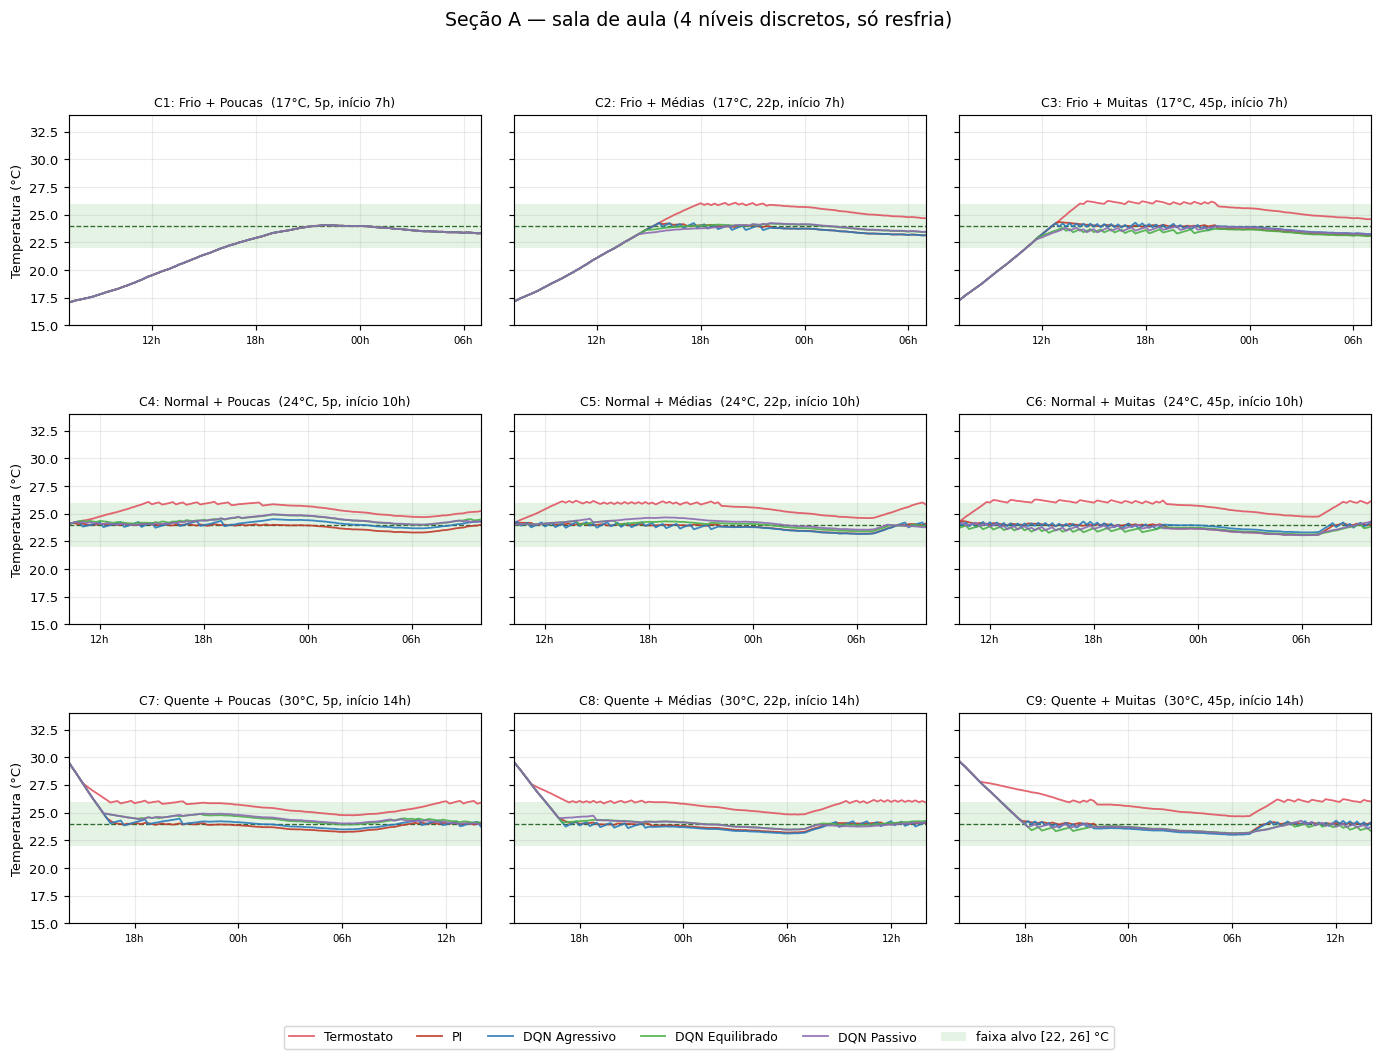

In [3]:
def grade(traj, cenarios, cfg, titulo, ylim, banda, arquivo, mostrar_tarifa=False):
    """Grade 3x3: um subplot por cenário, todos os controladores sobrepostos."""
    fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=True,
                             gridspec_kw={"hspace": 0.42, "wspace": 0.08})
    axes = axes.flatten()
    for i, s in enumerate(cenarios):
        ax = axes[i]
        qualquer = traj[list(traj)[0]][s["id"]]
        h0, h1 = qualquer["hour_float"].min(), qualquer["hour_float"].max()
        if mostrar_tarifa: faixas_tarifa(ax, cfg, h0, h1)
        ax.axhspan(*banda, color="#4daf4a", alpha=0.15, lw=0)
        ax.axhline(cfg.ideal_temp, color="#2f6b2f", ls="--", lw=0.9)
        for nome, porcen in traj.items():
            df = porcen[s["id"]]
            ax.plot(df["hour_float"], df["temperature"], lw=1.25,
                    color=CORES.get(nome, "#888"), label=nome, alpha=0.9)
        eixo_horas(ax, h0, h1)
        ax.set_title(f"{s['id']}: {s['condition']} + {s['occupancy_label']}"
                     f"  ({s['start_temp']:.0f}°C, {s['occupancy']}p, início {s['hour']}h)",
                     fontsize=8.5)
        ax.set_ylim(*ylim)
        if i % 3 == 0: ax.set_ylabel("Temperatura (°C)")
    h, l = axes[0].get_legend_handles_labels()
    extra = [Patch(facecolor="#4daf4a", alpha=.15)]
    el = [f"faixa alvo [{banda[0]:g}, {banda[1]:g}] °C"]
    if mostrar_tarifa:
        extra.append(Patch(facecolor="#e05561", alpha=.13)); el.append("posto de ponta")
    fig.legend(h+extra, l+el, loc="lower center", ncol=min(7, len(l)+len(el)),
               fontsize=8.5, bbox_to_anchor=(0.5, -0.015))
    fig.suptitle(titulo, fontsize=13, y=0.98)
    fig.tight_layout(rect=[0, 0.035, 1, 0.965])
    fig.savefig(f"{SAVE}/{arquivo}", bbox_inches="tight"); plt.show()

grade(traj_A, SCEN, CFG_A,
      "Seção A — sala de aula (4 níveis discretos, só resfria)",
      ylim=(15, 34), banda=(22, 26), arquivo="A_grade_cenarios.png")

### Leitura da Seção A

Três padrões que a grade revela e que nenhuma tabela mostra:

1. **C1–C3 (partida fria, 17 °C):** todos os controladores ficam abaixo da faixa
   por horas. O equipamento só resfria — a única ação correta é esperar o
   aquecimento natural. É por isso que C1 é excluído pelo filtro de
   controlabilidade.
2. **O termostato (vermelho) assenta no teto**, os demais no centro. É a diferença
   entre \|T−24\| de 2,10 e de ~0,8.
3. **Nos cenários quentes de alta ocupação** aparece o *pulldown*: queda rápida
   inicial e depois regime.


## Seção B — Laboratório (contínuo, bidirecional)

Aquecimento habilitado, tarifa real da Enel com o posto de ponta em vermelho, e a
faixa de tolerância **±0,5 °C** em verde — dez vezes mais estreita que a faixa de
conforto da Seção A. Note a escala do eixo Y.


controladores: ['PI bidirecional', 'SAC Equilibrado', 'SAC Precisao', 'TD3 Economico', 'TD3 Equilibrado', 'TD3 Precisao']


/tmp/ipykernel_802820/3703640003.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.035, 1, 0.965])


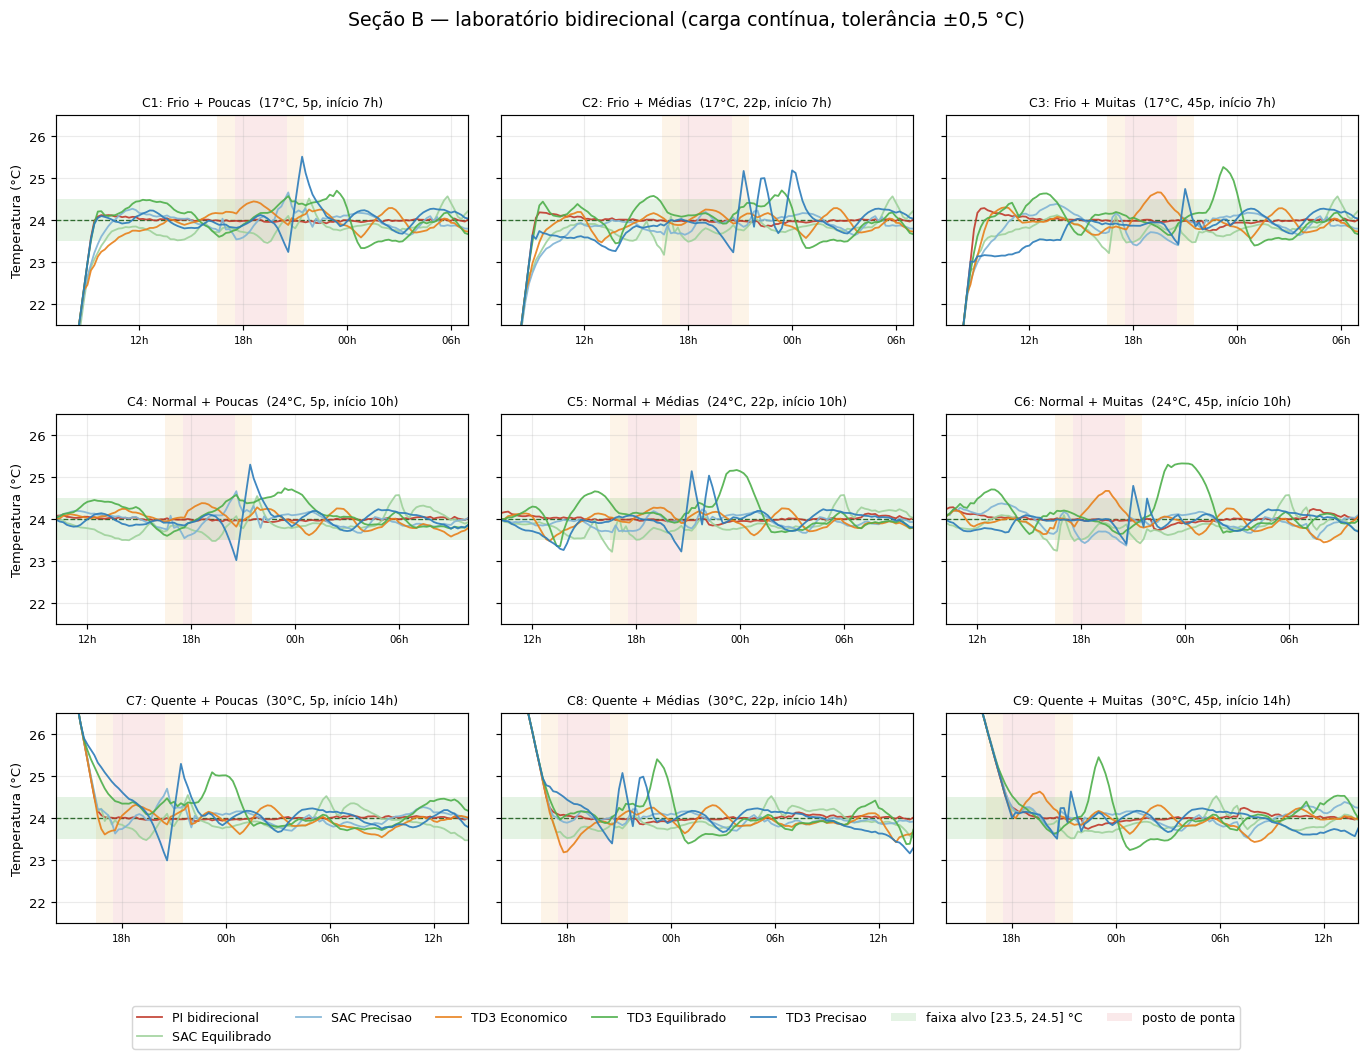

In [4]:
CFG_B = config_for_lab2("Lab_Equilibrado")
ctrl_B = {"PI bidirecional": (PIController(CFG_B, kp=1.3, ki=0.2, discrete=False), True, CFG_B)}
for path in sorted(glob.glob("../models_lab2/*_lab2.zip")):
    meta = path.replace(".zip", "_config.json")
    algo, perfil = "TD3", "Lab_Equilibrado"
    if os.path.exists(meta):
        with open(meta, encoding="utf-8") as fh: m = json.load(fh)
        algo, perfil = m.get("algo", algo), m.get("profile", perfil)
        if m.get("seed", 0) != 0: continue
    cls = {"TD3": TD3, "SAC": SAC}.get(algo)
    if cls: ctrl_B[f"{algo} {perfil.replace('Lab_','')}"] = (
        cls.load(path, device="cpu"), False, config_for_lab2(perfil))

traj_B = coletar(ctrl_B, SCEN)
print("controladores:", list(traj_B))

grade(traj_B, SCEN, CFG_B,
      "Seção B — laboratório bidirecional (carga contínua, tolerância ±0,5 °C)",
      ylim=(21.5, 26.5), banda=(23.5, 24.5), arquivo="B_grade_cenarios.png",
      mostrar_tarifa=True)

## Detalhe de um dia: temperatura, carga e custo

Cenário **C6 (Normal + Muitas)**, que atravessa o posto de ponta com sala cheia —
o caso em que antecipar valeria mais. Três painéis alinhados no tempo.

No painel do meio, **azul resfria e vermelho aquece**. Antecipação apareceria como
azul intenso antes de 17h30 e quase nada dentro da faixa vermelha.


/tmp/ipykernel_802820/4157638112.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(f"{SAVE}/B_detalhe_dia_{ALVO}.png",


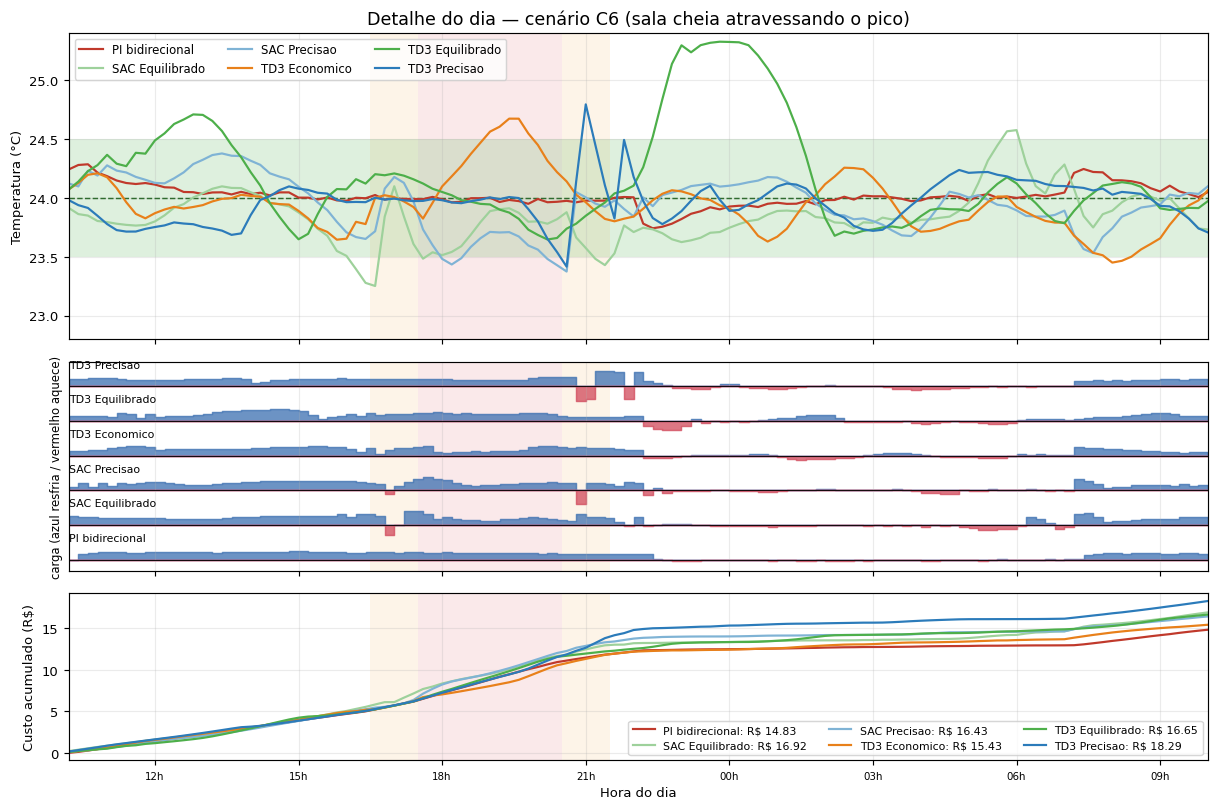

In [5]:
ALVO = "C6"
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1.5, 1.2], "hspace": 0.1})
qualquer = traj_B[list(traj_B)[0]][ALVO]
h0, h1 = qualquer["hour_float"].min(), qualquer["hour_float"].max()

for ax in axes: faixas_tarifa(ax, CFG_B, h0, h1)
axes[0].axhspan(23.5, 24.5, color="#4daf4a", alpha=0.18, lw=0)
axes[0].axhline(24.0, color="#2f6b2f", ls="--", lw=1.0)
for nome, porcen in traj_B.items():
    df = porcen[ALVO]
    axes[0].plot(df["hour_float"], df["temperature"], lw=1.5,
                 color=CORES.get(nome, "#888"), label=nome)
    axes[2].plot(df["hour_float"], df["cost_brl"].cumsum(), lw=1.5,
                 color=CORES.get(nome, "#888"),
                 label=f"{nome}: R$ {df['cost_brl'].sum():.2f}")
axes[0].set_ylabel("Temperatura (°C)"); axes[0].set_ylim(22.8, 25.4)
axes[0].legend(fontsize=8, ncol=3, loc="upper left")
axes[0].set_title(f"Detalhe do dia — cenário {ALVO} (sala cheia atravessando o pico)",
                  fontsize=12)

# Painel do meio: carga com sinal, empilhada por controlador
for i, (nome, porcen) in enumerate(traj_B.items()):
    df = porcen[ALVO]
    off = i * 2.3
    carga = df["load"] if "load" in df else df["action"] * 0
    axes[1].fill_between(df["hour_float"], off, off + carga.clip(lower=0),
                         step="post", color="#3b6fb0", alpha=0.75)
    axes[1].fill_between(df["hour_float"], off, off + carga.clip(upper=0),
                         step="post", color="#d1495b", alpha=0.75)
    axes[1].axhline(off, color="black", lw=0.6)
    axes[1].text(h0, off + 1.1, nome, fontsize=7.5, va="bottom")
axes[1].set_ylabel("carga (azul resfria / vermelho aquece)", fontsize=8)
axes[1].set_yticks([])

axes[2].set_ylabel("Custo acumulado (R$)")
axes[2].legend(fontsize=7.5, ncol=3)
eixo_horas(axes[2], h0, h1, passo=3); axes[2].set_xlabel("Hora do dia")
fig.tight_layout(); fig.savefig(f"{SAVE}/B_detalhe_dia_{ALVO}.png",
                                bbox_inches="tight"); plt.show()

## Mapa de calor: desempenho por cenário

Onde cada controlador é forte e onde falha. Vermelho = fora da tolerância.


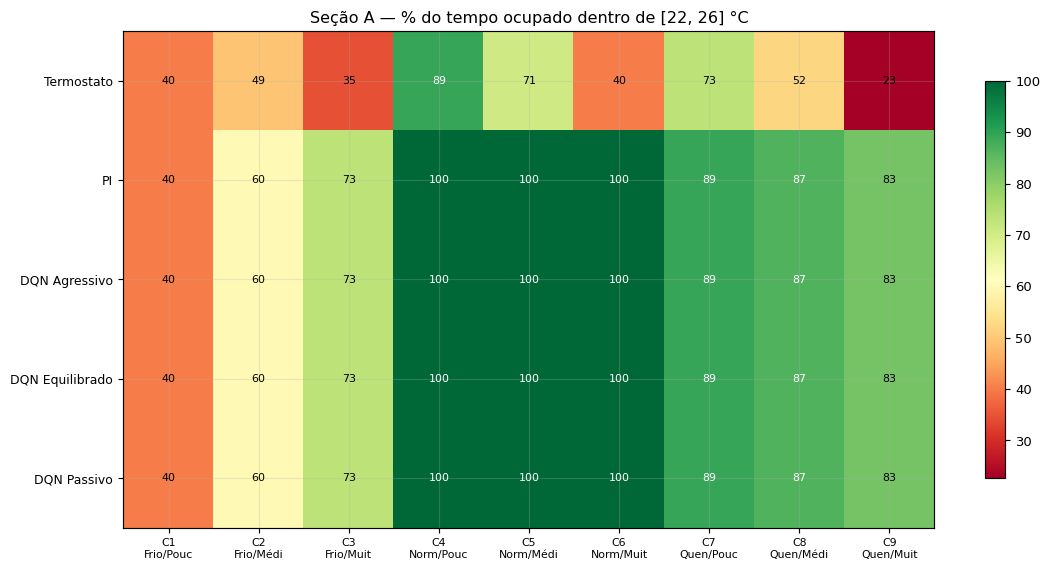

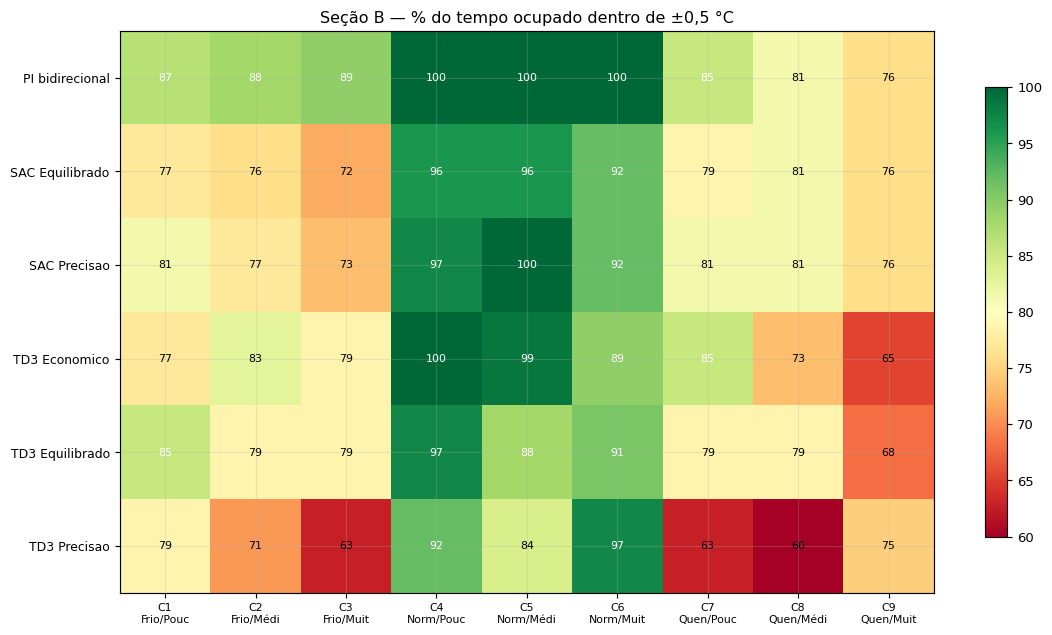

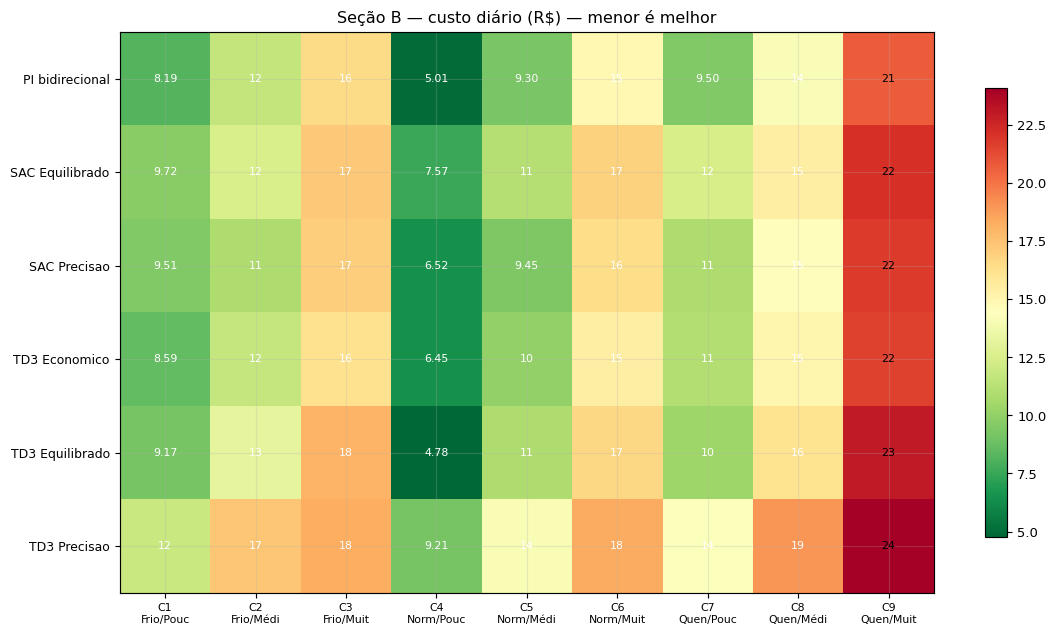

In [6]:
def mapa(traj, cfg, metrica, rotulo, arquivo, cmap="RdYlGn", inverter=False):
    nomes, ids = list(traj), [s["id"] for s in SCEN]
    M = np.zeros((len(nomes), len(ids)))
    for i, n in enumerate(nomes):
        for j, sid in enumerate(ids):
            M[i, j] = episode_metrics(traj[n][sid], cfg)[metrica]
    fig, ax = plt.subplots(figsize=(11, 0.62 * len(nomes) + 2.4))
    im = ax.imshow(M, aspect="auto", cmap=cmap + ("_r" if inverter else ""))
    ax.set_xticks(range(len(ids)))
    ax.set_xticklabels([f"{s['id']}\n{s['condition'][:4]}/{s['occupancy_label'][:4]}"
                        for s in SCEN], fontsize=7.5)
    ax.set_yticks(range(len(nomes))); ax.set_yticklabels(nomes, fontsize=8.5)
    for i in range(len(nomes)):
        for j in range(len(ids)):
            ax.text(j, i, f"{M[i,j]:.0f}" if M[i,j] >= 10 else f"{M[i,j]:.2f}",
                    ha="center", va="center", fontsize=7.5,
                    color="black" if 20 < M[i,j] < 85 or M[i,j] < 2 else "white")
    ax.set_title(rotulo, fontsize=11)
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout(); fig.savefig(f"{SAVE}/{arquivo}", bbox_inches="tight"); plt.show()

mapa(traj_A, CFG_A, "comfort_wide_pct",
     "Seção A — % do tempo ocupado dentro de [22, 26] °C", "A_mapa_conforto.png")
mapa(traj_B, CFG_B, "in_tolerance_pct",
     "Seção B — % do tempo ocupado dentro de ±0,5 °C", "B_mapa_tolerancia.png")
mapa(traj_B, CFG_B, "cost_brl_day",
     "Seção B — custo diário (R$) — menor é melhor", "B_mapa_custo.png",
     cmap="RdYlGn", inverter=True)

## Tabela consolidada


In [7]:
def resumo(traj, cfg, chaves):
    linhas = []
    for n, porcen in traj.items():
        ms = [episode_metrics(df, cfg) for df in porcen.values()]
        linhas.append({"controlador": n, **{k: round(float(np.mean([m[k] for m in ms])), 3)
                                            for k in chaves}})
    return pd.DataFrame(linhas)

print("SEÇÃO A — sala de aula (média dos 9 cenários)")
display(resumo(traj_A, CFG_A, ["comfort_wide_pct", "comfort_narrow_pct",
                               "abs_dev_from_ideal", "overheat_pct",
                               "energy_kwh_day", "changes_per_hour"])
        .sort_values("comfort_wide_pct", ascending=False))

print("\nSEÇÃO B — laboratório bidirecional (média dos 9 cenários)")
display(resumo(traj_B, CFG_B, ["in_tolerance_pct", "temp_std", "abs_dev_from_ideal",
                               "cost_brl_day", "peak_cost_brl", "changes_per_hour"])
        .sort_values("in_tolerance_pct", ascending=False))

SEÇÃO A — sala de aula (média dos 9 cenários)


,controlador,comfort_wide_pct,comfort_narrow_pct,abs_dev_from_ideal,overheat_pct,energy_kwh_day,changes_per_hour
1,PI,81.333,77.333,0.978,4.593,10.404,1.046
2,DQN Agressivo,81.333,77.333,1.029,4.593,11.658,1.222
3,DQN Equilibrado,81.333,77.333,1.136,4.593,10.896,0.778
4,DQN Passivo,81.333,77.185,1.118,4.593,10.791,0.787
0,Termostato,52.444,13.630,2.216,33.481,7.548,0.972



SEÇÃO B — laboratório bidirecional (média dos 9 cenários)


,controlador,in_tolerance_pct,temp_std,abs_dev_from_ideal,cost_brl_day,peak_cost_brl,changes_per_hour
0,PI bidirecional,89.630,0.926,0.386,12.217,3.231,0.611
2,SAC Precisao,84.444,0.978,0.516,13.023,3.346,1.875
3,TD3 Economico,83.407,1.001,0.521,12.888,3.102,1.546
1,SAC Equilibrado,82.815,0.990,0.570,13.916,3.350,1.926
4,TD3 Equilibrado,82.667,1.012,0.558,13.585,3.322,2.037
5,TD3 Precisao,75.852,1.011,0.572,16.282,4.187,1.375


## Nota metodológica

As trajetórias usam **semente de avaliação 0** e modelos da **semente de treino 0**.
Para conclusões quantitativas use `evaluate_lab2.py`, que faz média sobre múltiplas
sementes — a variância entre sementes de treino chegou a **97,8 % / 96,4 % / 5,3 %**
na mesma configuração de DQN, então uma trajetória isolada ilustra comportamento,
não desempenho.
